# SHAP Analysis

## Imports and Function Definition

In [40]:
import pandas as pd
import numpy as np
import joblib
import json
import shap
import matplotlib.pyplot as plt


# Custom Tokenizer
def split_comma_skills(skill_string):
    if not isinstance(skill_string, str):
        return []
    return [skill.strip() for skill in skill_string.split(',')]

print("Libraries imported and custom tokenizer defined.")

Libraries imported and custom tokenizer defined.


## Load Pipeline and Feature Names

In [41]:
MODEL_PATH = "../api/saved_models/rf_model.pkl"
FEATURES_PATH = "../data/training/feature_names.json"

pipeline = joblib.load(MODEL_PATH)

# Load the feature names extracted from the ColumnTransformer
with open(FEATURES_PATH, "r") as f:
    feature_names = json.load(f)

print("Pipeline and feature names loaded successfully.")

Pipeline and feature names loaded successfully.


## Preprocessing Data for SHAP

In [42]:
# Load sample candidates to explain
DATA_PATH = "../data/training/training_data.csv"
df = pd.read_csv(DATA_PATH)

# Drop the columns as in training
cols_to_drop = ['AI Score (0-100)', 'Resume_ID', 'Name', 'Salary Expectation ($)']
X_raw = df.drop(columns=cols_to_drop).head(5) # Use first 5 candidate for testing

# Isolate the preprocessor and transform the raw data
preprocessor = pipeline.named_steps['preprocessor']
X_transformed = preprocessor.transform(X_raw)

print(f"Transformed data shape: {X_transformed.shape}")
print("Data successfully converted to numerical arrays for SHAP.")

Transformed data shape: (5, 37)
Data successfully converted to numerical arrays for SHAP.


## Initializing TreeSHAP

In [43]:
# Isolate trained Random Forest from the pipeline
rf_model = pipeline.named_steps['regressor']

# Initialize the TreeExplainer
explainer = shap.TreeExplainer(rf_model) # pass model

# Calculate SHAP values for our sample candidates
shap_values = explainer.shap_values(X_transformed)

print(f"Calculated SHAP values for {X_transformed.shape[0]} candidates.")

Calculated SHAP values for 5 candidates.


## Visualizing Feature Impact

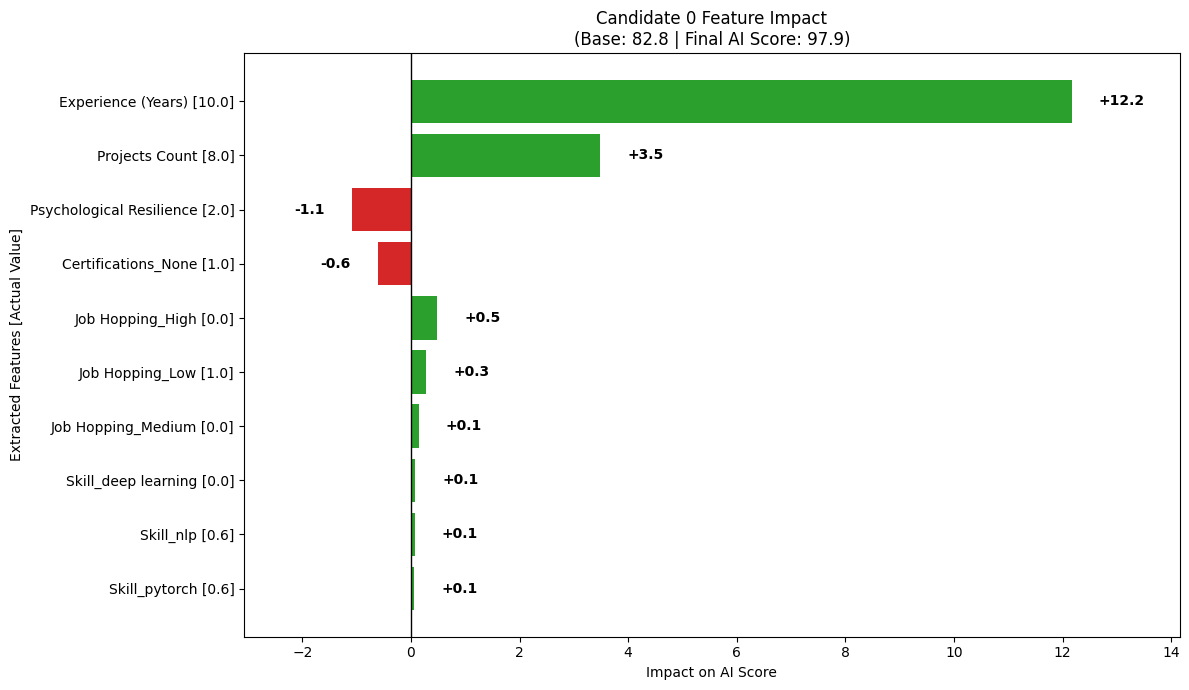

In [44]:
def plot_custom_shap(candidate_idx, shap_vals, feature_cols, base_val, actual_data):
    """
    Generates a diverging horizontal bar chart for a single candidate.
    Includes the actual feature value in the label and removes noise.
    """
    candidate_shap = shap_vals[candidate_idx]
    candidate_features = actual_data[candidate_idx]

    # Create DataFrame
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'SHAP_Value': candidate_shap,
        'Actual_Value': candidate_features
    })

    # Filter out visual noise
    importance_df = importance_df[importance_df['SHAP_Value'].abs() >= 0.05] # removes impact between -0.05 and 0.05

    # Sort by absolute magnitude
    importance_df['Abs_Value'] = importance_df['SHAP_Value'].abs()
    importance_df = importance_df.sort_values(by='Abs_Value', ascending=True)

    # Format the labels to include the actual value
    importance_df['Label'] = importance_df.apply(
        lambda row: f"{row['Feature']} [{row['Actual_Value']:.1f}]"
        if isinstance(row['Actual_Value'], (int, float))
        else f"{row['Feature']} [{row['Actual_Value']}]", axis=1
    )

    # Define colors
    colors = ['#2ca02c' if val > 0 else '#d62728' for val in importance_df['SHAP_Value']]

    # Create the plot
    plt.figure(figsize=(12, 7))
    bars = plt.barh(importance_df['Label'], importance_df['SHAP_Value'], color=colors)

    plt.axvline(0, color='black', linewidth=1)

    final_score = base_val + importance_df['SHAP_Value'].sum()
    plt.title(f"Candidate {candidate_idx} Feature Impact\n(Base: {base_val:.1f} | Final AI Score: {final_score:.1f})")
    plt.xlabel("Impact on AI Score")
    plt.ylabel("Extracted Features [Actual Value]")

    # Add numerical value labels
    for bar in bars:
        xval = bar.get_width()
        x_offset = 0.5 if xval > 0 else -0.5
        ha_alignment = 'left' if xval > 0 else 'right'

        plt.text(xval + x_offset,
                 bar.get_y() + bar.get_height()/2,
                 f"{xval:+.1f}",
                 va='center', ha=ha_alignment,
                 fontsize=10, fontweight='bold')

    plt.margins(x=0.15)
    plt.tight_layout()
    plt.show()

# Get the base expected value
base_value = explainer.expected_value
if isinstance(base_value, np.ndarray):
    base_value = base_value[0]

# Pass X_transformed as a dense array in case ColumnTransformer outputs a sparse matrix so the function can extract the actual values
dense_X_transformed = np.array(X_transformed.todense()) if hasattr(X_transformed, 'todense') else np.array(X_transformed)

plot_custom_shap(0, shap_values, feature_names, base_value, dense_X_transformed)

## Edge Case Testing

Custom candidate created:


,Experience (Years),Projects Count,Education,Certifications,Job Role,Skills,Structural Adherence,Adaptive Fluidity,Interpersonal Influence,Execution Velocity,Psychological Resilience,Job Hopping
0,8,12,PhD,None,Software Engineer,"Python, PyTorch, fast prototyping, hacking",1,5,4,5,3,High



Generating SHAP visualization...


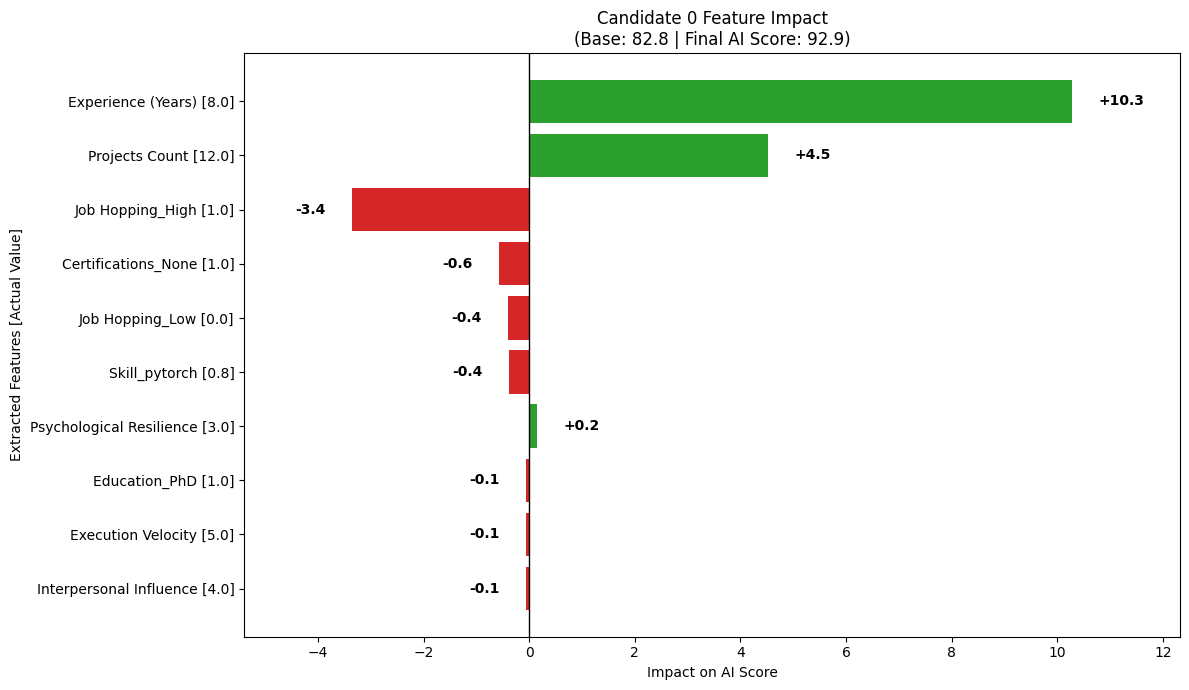

In [45]:
custom_candidate = pd.DataFrame([{
    'Experience (Years)': 8,
    'Projects Count': 12,
    'Education': 'PhD',
    'Certifications': 'None',
    'Job Role': 'Software Engineer', 
    'Skills': 'Python, PyTorch, fast prototyping, hacking',
    # Injected Behavioral Metrics
    'Structural Adherence': 1,        # Hates rules and legacy constraints
    'Adaptive Fluidity': 5,           # Thrives in chaos
    'Interpersonal Influence': 4,     # Highly persuasive
    'Execution Velocity': 5,          # Moves fast, breaks things
    'Psychological Resilience': 3,    # Average emotional stability
    'Job Hopping': 'High'             # Jumps ship frequently
}])

print("Custom candidate created:")
display(custom_candidate)

# Transform the raw data into numerical arrays
custom_transformed = preprocessor.transform(custom_candidate)
dense_custom_X = np.array(custom_transformed.todense()) if hasattr(custom_transformed, 'todense') else np.array(custom_transformed)

# Calculate SHAP values
custom_shap_values = explainer.shap_values(custom_transformed)

# Plot the diverging bar chart
print("\nGenerating SHAP visualization...")
plot_custom_shap(
    candidate_idx=0, 
    shap_vals=custom_shap_values, 
    feature_cols=feature_names, 
    base_val=base_value, 
    actual_data=dense_custom_X
)